# The Scholarship Illusion - Sharp and Fuzzy Regression Discontinuity

A university awards a merit scholarship to every applicant who scores **65 or above**
on its entrance exam. Years later, the board wants to know whether the scholarship
actually raised graduates' earnings. The first analysis compares mean earnings above
and below the cutoff and finds a gap of almost **\$15,000** - a number nobody should
believe, because high scorers out-earn low scorers *whether or not anyone hands them
money*. This tutorial uses **regression discontinuity (RDD)** to recover the credible
effect hiding inside that illusion: about \$2,600 for receiving the *offer*, and about
\$4,000 for the students the offer actually moves into the program.

Along the way we cover the full RD workflow in `diff-diff`:

- **`RDPlot`** - the Calonico-Cattaneo-Titiunik (2015) data-driven RD plot, the
  standard first look at any discontinuity design.
- **Sharp RD** with `RegressionDiscontinuity` - local-polynomial estimation with
  MSE-optimal bandwidths and robust bias-corrected inference (Calonico, Cattaneo &
  Titiunik 2014), matching R's `rdrobust` defaults.
- **The validity toolkit** - covariate balance, placebo cutoffs, and bandwidth
  sensitivity.
- **Fuzzy RD** - imperfect take-up, the first stage, and the complier LATE.
- **Covariate adjustment** (Calonico, Cattaneo, Farrell & Titiunik 2019) - and why
  covariates play a completely different role in RD than in DiD.


## When is RDD the right tool?

This library is mostly about difference-in-differences, which needs treated and
comparison groups observed before and after treatment (as a panel or as repeated
cross-sections, depending on the estimator) plus a parallel-trends assumption. RDD
replaces that data demand with a design requirement: **treatment assigned by a known
rule** - a score crossing a threshold.

- **You have pre/post data on treated and comparison groups** and believe some version
  of parallel trends - use the DiD estimators.
- **You have a single cross-section and an assignment rule** (an eligibility score, a
  vote share, an age or income threshold) - use `RegressionDiscontinuity`. If nobody
  can precisely manipulate their score, units just above and just below the cutoff
  should differ only in treatment. That comparability is the design's *identifying
  assumption* - made plausible by the rule, not guaranteed by it.
- **The price** is locality: RDD identifies the effect *at the cutoff*, not an average
  over the whole population. That is the estimand's honest scope, not a defect.

Identification rests on **continuity**: absent treatment, average potential outcomes
are smooth functions of the running variable at the cutoff. That requires that nothing
*else* jumps at the threshold (no other program shares the cutoff) and that units do
not sort precisely around it. Continuity itself is untestable - what Act 4 checks are
its testable implications.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from diff_diff import RDPlot, RegressionDiscontinuity


## The data

We simulate the admissions cohort so the truth is known by construction - every
estimate below can be checked against it. The ingredients:

- **Running variable**: an exam `score`, roughly bell-shaped around 64, cutoff at 65.
  Just under half the cohort clears it.
- **Baseline earnings** rise *smoothly and nonlinearly* in the score (linear plus
  convex term) - this is the confound that makes the naive comparison a trap.
- **Predetermined covariates** (`parental_income`, `hs_gpa`) vary smoothly with the
  score and independently move earnings. Smooth-in-score means *balanced at the
  cutoff* - we will verify that rather than assume it.
- **Imperfect take-up**: crossing the cutoff triggers the *offer*, but only 72% of
  offered students enroll with the scholarship, and 6% of below-cutoff students
  enroll on equivalent outside aid. The treatment variable is therefore **funded
  enrollment** (scholarship-funded above the cutoff, outside-aid-funded below), and
  take-up is monotone in the offer by construction.
- **The truth**: funded enrollment raises earnings by exactly **\$4,000**. The
  offer therefore raises *average* earnings at the cutoff by
  (0.72 - 0.06) x \$4,000 = **\$2,640** - the intent-to-treat effect.


In [2]:
SEED = 25
N = 8_000
CUTOFF = 65.0

TRUE_EFFECT = 4_000.0  # effect of funded enrollment, at the cutoff
P_ENROLL_IF_OFFERED = 0.72  # P(enroll | offered); complier share = 0.72 - 0.06
P_ALWAYS = 0.06  # below-cutoff students who find equivalent outside aid

rng = np.random.default_rng(SEED)

ability = rng.normal(0.0, 1.0, N)
score = np.clip(64 + 11 * ability + rng.normal(0, 4, N), 30, 100)

# predetermined covariates: smooth in the score, hence balanced at the cutoff
parental_income = np.clip(
    45_000 + 600 * (score - 60) + rng.normal(0, 15_000, N), 8_000, None
)
hs_gpa = np.clip(2.9 + 0.016 * (score - 60) + rng.normal(0, 0.30, N), 0.0, 4.0)

# the offer is deterministic in the score; enrollment is not
offer = (score >= CUTOFF).astype(int)
u = rng.uniform(size=N)
enrolled = np.where(offer == 1, (u < P_ENROLL_IF_OFFERED), (u < P_ALWAYS)).astype(int)

# earnings at 28: smooth nonlinear baseline + covariates + the true effect
base = 24_000 + 320 * score + 7.0 * (score - 60) ** 2
earnings = (
    base
    + 0.35 * (parental_income - 45_000)
    + 4_000 * (hs_gpa - 2.9)
    + TRUE_EFFECT * enrolled
    + rng.normal(0, 4_500, N)
)

df = pd.DataFrame(
    {
        "score": score,
        "offer": offer,
        "enrolled": enrolled,
        "earnings": earnings,
        "parental_income": parental_income,
        "hs_gpa": hs_gpa,
    }
)

true_itt = (P_ENROLL_IF_OFFERED - P_ALWAYS) * TRUE_EFFECT
print(f"cohort: {len(df):,} students, {df.offer.mean():.1%} above the cutoff")
print(f"take-up above cutoff: {df.loc[df.offer == 1, 'enrolled'].mean():.1%}")
print(f"take-up below cutoff: {df.loc[df.offer == 0, 'enrolled'].mean():.1%}")
print(f"true effect of enrolling: ${TRUE_EFFECT:,.0f}")
print(f"true intent-to-treat effect of the offer: ${true_itt:,.0f}")


cohort: 8,000 students, 46.9% above the cutoff
take-up above cutoff: 73.6%
take-up below cutoff: 6.0%
true effect of enrolling: $4,000
true intent-to-treat effect of the offer: $2,640


## Act 1: the illusion

The board's first analyst compares mean earnings on either side of the cutoff.


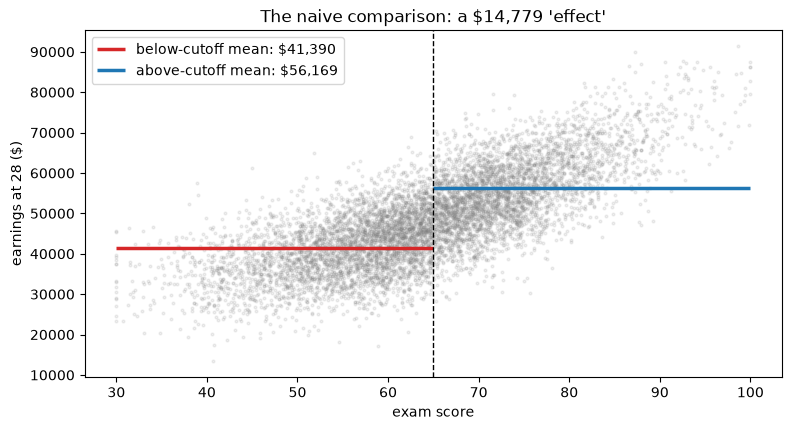

naive above-vs-below gap: $14,779
true offer effect at the cutoff: $2,640


In [3]:
naive = (
    df.loc[df.offer == 1, "earnings"].mean()
    - df.loc[df.offer == 0, "earnings"].mean()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(df.score, df.earnings, s=4, alpha=0.12, color="tab:gray")
for mask, color, lbl in (
    (df.offer == 0, "tab:red", "below-cutoff mean"),
    (df.offer == 1, "tab:blue", "above-cutoff mean"),
):
    m = df.loc[mask, "earnings"].mean()
    lo, hi = df.loc[mask, "score"].min(), df.loc[mask, "score"].max()
    ax.hlines(m, lo, hi, color=color, lw=2.5, label=f"{lbl}: ${m:,.0f}")
ax.axvline(CUTOFF, color="k", ls="--", lw=1)
ax.set_xlabel("exam score")
ax.set_ylabel("earnings at 28 ($)")
ax.set_title(f"The naive comparison: a ${naive:,.0f} 'effect'")
ax.legend(loc="upper left")
plt.show()

print(f"naive above-vs-below gap: ${naive:,.0f}")
print(f"true offer effect at the cutoff: ${true_itt:,.0f}")


**\$14,779 - more than five times the true \$2,640.** The picture shows why: earnings
climb steeply with the score everywhere, so the two group means mostly measure *who
scores high*, not *what the scholarship does*. Every student in the above-cutoff mean
outscored every student in the below-cutoff mean; the scholarship is a footnote to
that selection.

The RD idea is to stop comparing distant students and compare students *at the
threshold* - a 64.9 scorer and a 65.1 scorer are essentially the same applicant, but
one gets the offer.


## Act 2: look before you estimate - `RDPlot`

The standard first move in any RD analysis is the CCT (2015) **RD plot**: bin the
running variable with a data-driven partition, plot per-bin outcome means, and overlay
separate global polynomial fits on each side. `RDPlot` matches R's `rdplot()`
numbers on its supported surface (documented edge-case deviations live in the
methodology registry), including the default mimicking-variance bin selector
(`binselect="esmv"`),
whose bins deliberately preserve the raw data's vertical scatter instead of
oversmoothing it.

Two views: the full support (where the *trend* is the star), and a window around the
cutoff (where the *jump* becomes visible). For the zoomed panel we drop the global
polynomial order from the default `p=4` to `p=2` - a ten-point window has no curvature
that needs a quartic, and the calmer fit makes the discontinuity easier to read.


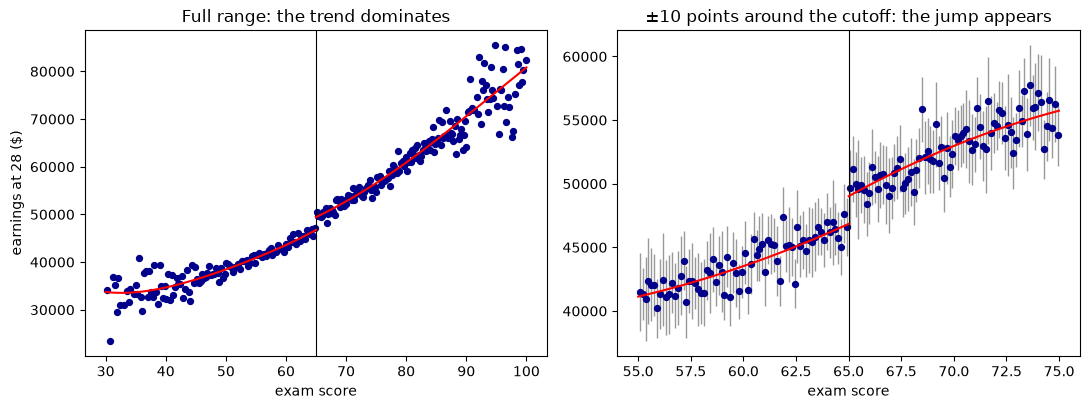

In [4]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.2))

full = RDPlot(cutoff=CUTOFF).fit(df, outcome="earnings", running="score")
full.plot(
    ax=axa,
    title="Full range: the trend dominates",
    xlabel="exam score",
    ylabel="earnings at 28 ($)",
)

window = df[df.score.between(CUTOFF - 10, CUTOFF + 10)]
zoom = RDPlot(cutoff=CUTOFF, p=2, ci=95).fit(
    window, outcome="earnings", running="score"
)
zoom.plot(
    ax=axb,
    title="±10 points around the cutoff: the jump appears",
    xlabel="exam score",
    ylabel="",
)
fig.tight_layout()
plt.show()


The full-range panel is the naive analyst's mistake drawn honestly: a steep, convex
climb from about \$34,000 to \$80,000, of which the cutoff jump is a barely visible
step. The zoomed panel - with 95% per-bin confidence intervals via `ci=95` - shows a
clean vertical break of roughly \$2,500-\$3,000 at 65, with smooth behavior on
either side. That break is what the estimator will now measure precisely.

`RDPlot` results also carry the full numeric surface (`summary()`, bin counts,
per-bin means and CIs in `vars_bins`) if you want the plot's ingredients rather than
its rendering.


## Act 3: sharp RD - the effect of the offer

`RegressionDiscontinuity` with default settings reproduces R's `rdrobust(y, x)`:
local-linear fits (`p=1`) with a triangular kernel on each side of the cutoff, a
common MSE-optimal bandwidth (`bwselect="mserd"`), and **robust bias-corrected (RBC)
inference** - the CCT (2014) fix for the fact that a naively-chosen optimal bandwidth
leaves first-order smoothing bias in the estimate. Because the *offer* is a
deterministic function of the score, treating `offer` as the treatment makes this a
**sharp** design, and the estimand is the effect of crossing the cutoff - the
intent-to-treat effect of the offer.


In [5]:
sharp = RegressionDiscontinuity(cutoff=CUTOFF).fit(
    df, outcome="earnings", running="score"
)
print(sharp.summary())


            Sharp Regression Discontinuity (rdrobust parity)            
Cutoff:               65
Estimand:             sharp (ATE at the cutoff)
Kernel: triangular     Bandwidth selector: mserd
Order (p, q): (1, 2)       VCE: nn (nnmatch=3)   Masspoints: adjust
N = 8000 (4250 left / 3750 right); effective N_h = 2636/2486, N_b = 3547/3260
h = [10.6211, 10.6211]   b = [17.0699, 17.0699]
------------------------------------------------------------------------
Method                Coef.  Std. Err.        z    P>|z|[95% Conf. Int.]
------------------------------------------------------------------------
Conventional      2616.1764   438.1046    5.972    0.000  [1757.5071, 3474.8457]
Bias-Corrected    2628.7444   438.1046    6.000    0.000  [1770.0751, 3487.4137]
Robust            2628.7444   524.4613    5.012    0.000  [1600.8193, 3656.6696]
------------------------------------------------------------------------
Note: canonical att/se/t_stat/p_value/conf_int are the ROBUST row
(att = bia

Reading the table:

- **Three rows, one estimator.** *Conventional* is the raw local-linear jump with its
  conventional standard error; *Bias-Corrected* subtracts the estimated smoothing
  bias (using a quadratic fit within the wider bandwidth `b`); *Robust* keeps the
  bias-corrected point estimate but inflates the standard error to account for the
  noise in the bias estimate itself. Under CCT's regularity and bandwidth conditions
  the **Robust row's inference is asymptotically valid** and generally improves
  finite-sample coverage (nominal coverage is not guaranteed in every sample) - and
  `diff-diff` binds the canonical fields (`att`, `se`, `p_value`, `conf_int`) to it. (R's `rdrobust` prints the conventional estimate in
  its headline column while taking inference from the robust row; that conventional
  estimate is available here as `att_conventional`.)
- **The answer**: \$2,629, 95% CI [\$1,601, \$3,657] - right on top of the \$2,640
  truth, from a bandwidth of about 10.6 score points selected by the data
  (`h = 10.62`, effective n ≈ 5,100 of the 8,000 students).
- The naive comparison was off by a factor of five; the local comparison at the
  threshold nails it.


In [6]:
print(f"offer effect (robust bias-corrected): ${sharp.att:,.0f}")
print(f"95% CI: [${sharp.conf_int[0]:,.0f}, ${sharp.conf_int[1]:,.0f}]")
print(f"selected bandwidth h: {sharp.h_left:.2f} score points")
print(f"true ITT: ${true_itt:,.0f}")


offer effect (robust bias-corrected): $2,629
95% CI: [$1,601, $3,657]
selected bandwidth h: 10.62 score points
true ITT: $2,640


## Act 4: the validity toolkit

An RD estimate is only as credible as its design checks. Three standard ones, all
runnable with the estimator itself.

### 4a. Covariate balance

Continuity has a testable implication: **predetermined covariates cannot jump at the
cutoff** - the scholarship offer cannot change your parents' income or your high-school
GPA. The balance test *is* an RD fit with the covariate as the outcome; a significant
jump would be evidence of sorting or manipulation.


In [7]:
for cov in ["parental_income", "hs_gpa"]:
    bal = RegressionDiscontinuity(cutoff=CUTOFF).fit(
        df, outcome=cov, running="score"
    )
    print(
        f"{cov:>16}: jump at cutoff = {bal.att:>8.3f}, "
        f"p = {bal.p_value:.3f}"
    )


 parental_income: jump at cutoff =   20.154, p = 0.987


          hs_gpa: jump at cutoff =   -0.023, p = 0.273


Parental income jumps by a statistically invisible \$20 (p = 0.99) and GPA by -0.02
points (p = 0.27) - no evidence of a discontinuity in either. Read this as *failure
to reject* smoothness: a significant jump would have contradicted the design, and its
absence supports it, but no balance test can prove continuity of the (unobservable)
potential-outcome functions.

### 4b. Placebo cutoffs

At any threshold where nothing is assigned, the estimator should find nothing.
Practical guides examine one or more artificial cutoffs across the support;
for this illustration we use the median score on each side - two well-supported
artificial thresholds - fitting each only on its own side's data so the true
discontinuity cannot enter the placebo window.


In [8]:
left = df[df.score < CUTOFF]
right = df[df.score >= CUTOFF]
for side in (left, right):
    fake = float(side.score.median())
    placebo = RegressionDiscontinuity(cutoff=fake).fit(
        side, outcome="earnings", running="score"
    )
    print(
        f"placebo cutoff {fake:.1f}: jump = ${placebo.att:>7,.0f}, "
        f"p = {placebo.p_value:.3f}"
    )


placebo cutoff 56.9: jump = $  1,162, p = 0.333


placebo cutoff 72.6: jump = $   -349, p = 0.742


No evidence of a jump at either placebo threshold (p = 0.33 and 0.74). Two placebo
cutoffs cannot rule out discontinuities everywhere else - but finding none where none
should exist is exactly the supporting evidence this check exists to collect.

### 4c. Bandwidth sensitivity

The bandwidth is the estimator's main tuning parameter, so referees will ask: does the
answer depend on it? Overriding the selector with fixed `h` values maps out the
sensitivity. One mechanical detail: passing `h` alone also sets the bias bandwidth
`b = h` (matching R), so each fit below is the complete RBC procedure run inside
that window - a joint sweep of both bandwidths, not a sweep of the local-linear
bandwidth with the bias correction held at the default fit's `b` (pass `b=` or
`rho=` explicitly for that design). Expect a mild bias-variance trade-off - tight
windows are noisier, wide windows lean harder on the polynomial approximation - but
the estimates should tell one consistent story.


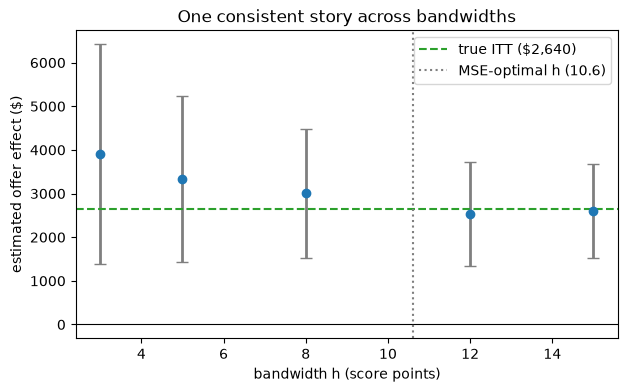

h =  3: att = $ 3,905, 95% CI [$ 1,395, $ 6,415]
h =  5: att = $ 3,341, 95% CI [$ 1,441, $ 5,242]
h =  8: att = $ 3,005, 95% CI [$ 1,527, $ 4,484]
h = 12: att = $ 2,534, 95% CI [$ 1,336, $ 3,732]
h = 15: att = $ 2,607, 95% CI [$ 1,528, $ 3,685]


In [9]:
h_grid = [3, 5, 8, 12, 15]
fits = [
    RegressionDiscontinuity(cutoff=CUTOFF, h=h).fit(
        df, outcome="earnings", running="score"
    )
    for h in h_grid
]

fig, ax = plt.subplots(figsize=(7, 4))
atts = [f.att for f in fits]
los = [f.att - f.conf_int[0] for f in fits]
his = [f.conf_int[1] - f.att for f in fits]
ax.errorbar(
    h_grid, atts, yerr=[los, his], fmt="o", color="tab:blue",
    ecolor="tab:gray", capsize=4, lw=2,
)
ax.axhline(true_itt, color="tab:green", ls="--", lw=1.5,
           label=f"true ITT (${true_itt:,.0f})")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(sharp.h_left, color="tab:gray", ls=":", lw=1.5,
           label=f"MSE-optimal h ({sharp.h_left:.1f})")
ax.set_xlabel("bandwidth h (score points)")
ax.set_ylabel("estimated offer effect ($)")
ax.set_title("One consistent story across bandwidths")
ax.legend()
plt.show()

for h, f in zip(h_grid, fits):
    print(
        f"h = {h:>2}: att = ${f.att:>6,.0f}, "
        f"95% CI [${f.conf_int[0]:>6,.0f}, ${f.conf_int[1]:>6,.0f}]"
    )


Every bandwidth from 3 to 15 points tells the same story - estimates between \$2,500
and \$3,900, every interval excluding zero and covering the truth. This is
*specification stability*: reassuring about the estimator's tuning, though - like all
the checks in this act - it supports the design without being able to establish it.

One check we have *not* run is a **manipulation (density) test** - McCrary (2008) /
Cattaneo, Jansson & Ma (2020) - which asks whether students bunch just above the
cutoff (they cannot here, because the simulation gives them no control over their
score). The test is packaged as `RDDensityTest` (Cattaneo, Jansson & Ma 2020,
rddensity parity): `from diff_diff import RDDensityTest`, then
`RDDensityTest(cutoff=65).fit(df, running="score")` returns the robust
bias-corrected density-discontinuity test. The estimator separately
handles *mass points* (repeated running-variable values) automatically via
`masspoints="adjust"`, the same default as R - a data-handling adjustment, not
a substitute for the manipulation test.


## Act 5: fuzzy RD - the effect of enrollment itself

The sharp estimate answers "what did the *offer* do?" - the right question for the
budget office. But the board asked what enrolling in the program does for students
who take it up, and only 74% of offered students enrolled (while 6% below the
cutoff enrolled on equivalent outside aid). Crossing the cutoff moves *take-up*
rather than determining it: a **fuzzy** design. Note the estimand carefully: the
treatment is **funded enrollment** (the `enrolled` column), not scholarship receipt
per se - though for the compliers the fuzzy design identifies, the enrollment the
offer induces *is* scholarship-funded.

Passing the observed take-up column via `takeup=` switches the estimand to the local
Wald ratio - the outcome jump divided by the take-up jump. Reading that ratio as the
**LATE for compliers at the cutoff** (the effect on students whose enrollment the
offer actually changed) requires the full instrumental-variables bundle, locally:
continuity, a *nonzero first stage* (crossing the cutoff must actually move
enrollment), an *exclusion restriction* (crossing affects earnings only through
enrollment - true by construction in this simulation, but an assumption the
estimator cannot verify), and *monotonicity* (no student avoids enrolling
*because* they crossed). The estimator reports the ratio; the causal reading is
yours to defend.


In [10]:
fuzzy = RegressionDiscontinuity(cutoff=CUTOFF).fit(
    df, outcome="earnings", running="score", takeup="enrolled"
)
print(fuzzy.summary())


            Fuzzy Regression Discontinuity (rdrobust parity)            
Cutoff:               65
Estimand:             fuzzy (LATE for compliers at the cutoff)
Kernel: triangular     Bandwidth selector: mserd
Order (p, q): (1, 2)       VCE: nn (nnmatch=3)   Masspoints: adjust
N = 8000 (4250 left / 3750 right); effective N_h = 1738/1601, N_b = 2718/2569
h = [6.3572, 6.3572]   b = [11.1093, 11.1093]
------------------------------------------------------------------------
             First-stage estimates (treatment take-up jump)             
Method                Coef.  Std. Err.        z    P>|z|[95% Conf. Int.]
------------------------------------------------------------------------
Conventional         0.6947     0.0270   25.764    0.000  [ 0.6418,  0.7475]
Bias-Corrected       0.7009     0.0270   25.994    0.000  [ 0.6480,  0.7537]
Robust               0.7009     0.0312   22.497    0.000  [ 0.6398,  0.7619]
------------------------------------------------------------------------
  

Two blocks now:

- **First stage**: crossing the cutoff raises enrollment by **70 percentage points**
  (0.701, robust CI [0.64, 0.76]) - comfortably strong, matching the designed
  0.72 - 0.06 = 0.66 jump. A weak first stage (a take-up jump near zero) would make
  the ratio explode; always read this block first.
- **Treatment effect**: the complier LATE is **\$3,765, CI [\$1,952, \$5,579]** -
  covering the \$4,000 truth. The interval is wider than the sharp one *here*, as
  fuzzy intervals often are (the first stage is estimated and below one) - though
  the two target different-scaled parameters, so their relative widths are not
  mechanically ordered.
- The two estimands follow the classic IV arithmetic approximately - ITT ≈ first
  stage x LATE (\$2,629 ≈ 0.70 x \$3,765 = \$2,637 here). The reported numbers do
  not obey it exactly, for two reasons: the fuzzy fit selects its own bandwidth for
  the ratio objective rather than reusing the sharp one, and the robust row
  bias-corrects the *first-order linearization of the ratio* (CCT 2014,
  Section 3.2) rather than dividing separately bias-corrected numerator and
  denominator.


## Act 6: covariates buy precision, not identification

In this library's DiD estimators, `covariates` changes the *identifying assumption*
(to conditional parallel trends). RD covariates do nothing of the sort: the CCFT
(2019) adjustment enters additively with a common coefficient pooled across sides,
the estimand is **unchanged**, and the payoff - when there is one - is a **shorter
confidence interval**. The gain is not automatic: CCFT's guarantee - an asymptotic variance no
larger than the unadjusted estimator's - holds when the covariates' best linear
association with the outcome is the same on both sides of the cutoff (the
common-coefficient specification), and the realized gain depends on how much outcome
variance the covariates absorb near the cutoff.

Balance at the cutoff is the recommended *testable sufficient condition* for
adjustment to leave the estimand unchanged - supported by Act 4a's falsification
checks, and true by construction in this simulation. Under imbalance the adjusted
estimator's probability limit shifts by the covariate jumps weighted by their
outcome coefficients, so adjustment is generally inconsistent unless that product
happens to be zero - and "adjusting for" imbalance cannot repair a broken design.
Balance first, then adjust.


In [11]:
adjusted = RegressionDiscontinuity(cutoff=CUTOFF).fit(
    df,
    outcome="earnings",
    running="score",
    covariates=["parental_income", "hs_gpa"],
)

for label, fit in (("unadjusted", sharp), ("adjusted", adjusted)):
    width = fit.conf_int[1] - fit.conf_int[0]
    print(
        f"{label:>10}: att = ${fit.att:,.0f}, "
        f"95% CI [${fit.conf_int[0]:,.0f}, ${fit.conf_int[1]:,.0f}] "
        f"(width ${width:,.0f})"
    )
shrink = 1 - (adjusted.conf_int[1] - adjusted.conf_int[0]) / (
    sharp.conf_int[1] - sharp.conf_int[0]
)
print(f"CI shortened by {shrink:.0%}")


unadjusted: att = $2,629, 95% CI [$1,601, $3,657] (width $2,056)
  adjusted: att = $2,581, 95% CI [$1,834, $3,329] (width $1,495)
CI shortened by 27%


Same estimand, same conclusion, and - in this simulation - a **27% shorter
interval**: the covariates soak up outcome variance that was pure noise for the jump. Bandwidths are covariate-aware
(the adjustment propagates into bandwidth selection, as in R), and collinear
covariates are dropped with a warning naming them under the default
`covs_drop=True`.


## Takeaways

- **The illusion was worth \$12,000.** The naive above-vs-below comparison said
  \$14,779; the design-based answer is \$2,629 for the offer (truth: \$2,640) and
  \$3,765 for compliers who enroll (truth: \$4,000). Selection on the running
  variable, not the scholarship, drove the gap.
- **Plot first.** `RDPlot` makes both the confound (the smooth climb) and the effect
  (the jump at 65) visible before any estimation - and matches R's `rdplot()`
  numbers on the supported surface.
- **Report the Robust row.** `diff-diff` binds `att`/`se`/`conf_int` to the robust
  bias-corrected inference of CCT (2014) - the row whose coverage is asymptotically
  valid under the method's conditions - while `summary()` prints all three rows and
  `att_conventional` keeps the conventional estimate available.
- **Falsification checks are built in.** Covariate balance (p = 0.99, 0.27), placebo
  cutoffs (p = 0.33, 0.74), and a bandwidth sweep that never moves the story - all
  with the same estimator, no extra machinery. They support the design's
  assumptions; continuity itself remains untestable.
- **Sharp vs fuzzy is offer vs treatment.** `takeup=` turns the cutoff into an
  instrument for enrollment; the first-stage block tells you whether that
  instrument is strong enough to lean on.
- **RD covariates ≠ DiD covariates.** Here they shortened the CI by 27% while
  leaving the estimand and the substantive conclusion unchanged (the finite-sample
  point estimate and the selected bandwidth can move) - precision, never
  identification.

### References

- Calonico, S., Cattaneo, M. D., & Titiunik, R. (2014). Robust Nonparametric
  Confidence Intervals for Regression-Discontinuity Designs. *Econometrica*, 82(6),
  2295-2326.
- Calonico, S., Cattaneo, M. D., & Titiunik, R. (2015). Optimal Data-Driven
  Regression Discontinuity Plots. *Journal of the American Statistical Association*,
  110(512), 1753-1769.
- Calonico, S., Cattaneo, M. D., Farrell, M. H., & Titiunik, R. (2019). Regression
  Discontinuity Designs Using Covariates. *Review of Economics and Statistics*,
  101(3), 442-451.
- Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2020). *A Practical Introduction to
  Regression Discontinuity Designs: Foundations*. Cambridge University Press.
- Cattaneo, M. D., Jansson, M., & Ma, X. (2020). Simple Local Polynomial Density
  Estimators. *Journal of the American Statistical Association*, 115(531),
  1449-1455.
- McCrary, J. (2008). Manipulation of the running variable in the regression
  discontinuity design: A density test. *Journal of Econometrics*, 142(2),
  698-714.
- Thistlethwaite, D. L., & Campbell, D. T. (1960). Regression-discontinuity analysis:
  An alternative to the ex post facto experiment. *Journal of Educational
  Psychology*, 51(6), 309-317.
